In [ ]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install mplcyberpunk
!pip install pyvista pyvistaqt trame
!pip install "pyvista[jupyter]"
!pip install vispy ipywidgets
!pip install plotly


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

import mplcyberpunk

plt.style.use("cyberpunk")

In [19]:
%matplotlib notebook

### Тестовый график

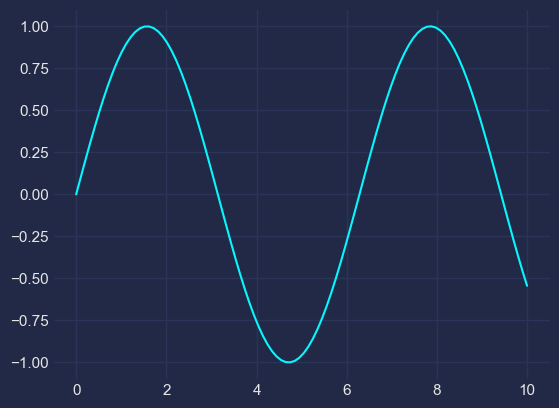

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

x = np.linspace(0, 10, 100)
line, = ax.plot(x, np.sin(x))


def update(frame):
    line.set_ydata(np.sin(x + frame * 0.1))
    return line,


ani = FuncAnimation(fig, update, frames=200, interval=50)

plt.show()

# График движения по орбите

In [15]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plt.subplots_adjust(bottom=0.35)

# параметры орбиты
a = 5
e = 0.4
inclination = 20

# центр орбиты
cx = 0
cy = 0
cz = 0

t = np.linspace(0, 2 * np.pi, 200)


def orbit(a, e, inc, cx, cy, cz):
    r = a * (1 - e ** 2) / (1 + e * np.cos(t))

    x = r * np.cos(t)
    y = r * np.sin(t)
    z = np.zeros_like(t)

    # наклон
    inc = np.radians(inc)
    z = y * np.sin(inc)
    y = y * np.cos(inc)

    # смещение центра
    x = x + cx
    y = y + cy
    z = z + cz

    return x, y, z


x, y, z = orbit(a, e, inclination, cx, cy, cz)

line, = ax.plot(x, y, z)
planet, = ax.plot([x[0]], [y[0]], [z[0]], 'o')

ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.set_zlim(-20, 20)

# -------- sliders --------

ax_a = plt.axes((0.2, 0.25, 0.65, 0.03))
ax_e = plt.axes((0.2, 0.20, 0.65, 0.03))
ax_i = plt.axes((0.2, 0.15, 0.65, 0.03))
ax_speed = plt.axes((0.2, 0.10, 0.65, 0.03))

ax_cx = plt.axes((0.2, 0.05, 0.65, 0.03))
ax_cy = plt.axes((0.2, 0.00, 0.65, 0.03))

slider_a = Slider(ax_a, "a", 1, 10, valinit=a)
slider_e = Slider(ax_e, "e", 0, 0.9, valinit=e)
slider_i = Slider(ax_i, "incl", 0, 90, valinit=inclination)
slider_speed = Slider(ax_speed, "speed", 0.1, 10, valinit=1)

slider_cx = Slider(ax_cx, "center x", -10, 10, valinit=0)
slider_cy = Slider(ax_cy, "center y", -10, 10, valinit=0)


def update(frame):
    a = slider_a.val
    e = slider_e.val
    inc = slider_i.val
    speed = slider_speed.val

    cx = slider_cx.val
    cy = slider_cy.val
    cz = 0

    x, y, z = orbit(a, e, inc, cx, cy, cz)

    line.set_data(x, y)
    line.set_3d_properties(z)

    idx = int(frame * speed) % len(x)

    planet.set_data([x[idx]], [y[idx]])
    planet.set_3d_properties([z[idx]])

    return line, planet


anim = FuncAnimation(fig, update, frames=len(t), interval=40)

plt.show()

<IPython.core.display.Javascript object>

# Вращения спутника вокруг планеты

In [13]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plt.subplots_adjust(bottom=0.40)

# параметры
a = 5
e = 0.4
inclination = 20

a_moon = 1.5
incl_moon = 30

theta_planet = 0
theta_moon = 0

# центр
cx = 0
cy = 0

t = np.linspace(0,2*np.pi,300)

def orbit_curve(a,e,inc):

    r = a*(1-e**2)/(1+e*np.cos(t))

    x = r*np.cos(t)
    y = r*np.sin(t)
    z = np.zeros_like(x)

    inc = np.radians(inc)

    z = y*np.sin(inc)
    y = y*np.cos(inc)

    return x,y,z


def orbit_point(a,e,inc,theta):

    r = a*(1-e**2)/(1+e*np.cos(theta))

    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = 0

    inc = np.radians(inc)

    z = y*np.sin(inc)
    y = y*np.cos(inc)

    return x,y,z


x,y,z = orbit_curve(a,e,inclination)

line, = ax.plot(x,y,z)
planet, = ax.plot([x[0]],[y[0]],[z[0]],'o')

moon_orbit_line, = ax.plot([],[],[])
moon, = ax.plot([],[],[],'o')

ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_zlim(-20,20)

# sliders

ax_a = plt.axes((0.2,0.30,0.65,0.03))
ax_speed = plt.axes((0.2,0.25,0.65,0.03))
ax_moon = plt.axes((0.2,0.20,0.65,0.03))
ax_cx = plt.axes((0.2,0.15,0.65,0.03))
ax_cy = plt.axes((0.2,0.10,0.65,0.03))

slider_a = Slider(ax_a,"planet orbit",1,10,valinit=a)
slider_speed = Slider(ax_speed,"speed",0.1,10,valinit=1)
slider_moon = Slider(ax_moon,"moon orbit",0.2,5,valinit=a_moon)

slider_cx = Slider(ax_cx,"center x",-10,10,valinit=0)
slider_cy = Slider(ax_cy,"center y",-10,10,valinit=0)

def update(frame):

    global theta_planet, theta_moon

    a = slider_a.val
    speed = slider_speed.val
    a_moon = slider_moon.val

    cx = slider_cx.val
    cy = slider_cy.val

    theta_planet += 0.02*speed
    theta_moon += 0.08*speed

    # обновляем орбиту планеты
    x,y,z = orbit_curve(a,e,inclination)
    x += cx
    y += cy

    line.set_data(x,y)
    line.set_3d_properties(z)

    # позиция планеты
    px,py,pz = orbit_point(a,e,inclination,theta_planet)

    px += cx
    py += cy

    planet.set_data([px],[py])
    planet.set_3d_properties([pz])

    # орбита луны
    mx,my,mz = orbit_curve(a_moon,0,incl_moon)

    mx += px
    my += py
    mz += pz

    moon_orbit_line.set_data(mx,my)
    moon_orbit_line.set_3d_properties(mz)

    # позиция луны
    mx,my,mz = orbit_point(a_moon,0,incl_moon,theta_moon)

    mx += px
    my += py
    mz += pz

    moon.set_data([mx],[my])
    moon.set_3d_properties([mz])

    return line,planet,moon,moon_orbit_line


ani = FuncAnimation(
    fig,
    update,
    interval=40,
    cache_frame_data=False
)

plt.show()

<IPython.core.display.Javascript object>

In [6]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig = plt.figure()
ax = fig.add_subplot(111)

a = 10
e = 0.6

theta = 0

line1, = ax.plot([], [], 'r')
line2, = ax.plot([], [], 'r')

star1, = ax.plot([], [], 'wo', markersize=10)
star2, = ax.plot([], [], 'wo', markersize=10)

bary, = ax.plot([0],[0],'r+')

t = np.linspace(0,2*np.pi,400)

def orbit_curve():

    r = a*(1-e**2)/(1+e*np.cos(t))

    x = r*np.cos(t)
    y = r*np.sin(t)

    return x,y

x,y = orbit_curve()

line1.set_data(-x/2,-y/2)
line2.set_data(x/2,y/2)

ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

def update(frame):

    global theta

    theta += 0.03

    r = a*(1-e**2)/(1+e*np.cos(theta))

    x = r*np.cos(theta)
    y = r*np.sin(theta)

    x1 = -x/2
    y1 = -y/2

    x2 = x/2
    y2 = y/2

    star1.set_data([x1],[y1])
    star2.set_data([x2],[y2])

    return star1,star2

ani = FuncAnimation(fig,update,interval=40)

plt.show()

<IPython.core.display.Javascript object>

C:\Users\SyperOlao\AppData\Local\Temp\ipykernel_18688\504724462.py:64: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = FuncAnimation(fig,update,interval=40)


In [9]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plt.subplots_adjust(bottom=0.25)

# параметры
a = 10
e = 0.6
incl = 30

theta = 0

# точки
star1, = ax.plot([],[],[],'wo',markersize=10)
star2, = ax.plot([],[],[],'wo',markersize=10)

orbit1, = ax.plot([],[],[],'r')
orbit2, = ax.plot([],[],[],'r')

bary, = ax.plot([0],[0],[0],'r+')

t = np.linspace(0,2*np.pi,400)

def orbit_curve(a,e,inc):

    r = a*(1-e**2)/(1+e*np.cos(t))

    x = r*np.cos(t)
    y = r*np.sin(t)
    z = np.zeros_like(x)

    inc = np.radians(inc)

    z = y*np.sin(inc)
    y = y*np.cos(inc)

    return x,y,z


x,y,z = orbit_curve(a,e,incl)

orbit1.set_data(-x/2,-y/2)
orbit1.set_3d_properties(-z/2)

orbit2.set_data(x/2,y/2)
orbit2.set_3d_properties(z/2)

ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_zlim(-20,20)

# sliders

ax_speed = plt.axes((0.2,0.1,0.65,0.03))
ax_a = plt.axes((0.2,0.05,0.65,0.03))

slider_speed = Slider(ax_speed,"speed",0.1,5,valinit=1)
slider_a = Slider(ax_a,"orbit size",5,20,valinit=a)

def update(frame):

    global theta

    speed = slider_speed.val
    a = slider_a.val

    theta += 0.02*speed

    r = a*(1-e**2)/(1+e*np.cos(theta))

    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = 0

    inc_r = np.radians(incl)

    z = y*np.sin(inc_r)
    y = y*np.cos(inc_r)

    x1,y1,z1 = -x/2,-y/2,-z/2
    x2,y2,z2 = x/2,y/2,z/2

    star1.set_data([x1],[y1])
    star1.set_3d_properties([z1])

    star2.set_data([x2],[y2])
    star2.set_3d_properties([z2])

    x,y,z = orbit_curve(a,e,incl)

    orbit1.set_data(-x/2,-y/2)
    orbit1.set_3d_properties(-z/2)

    orbit2.set_data(x/2,y/2)
    orbit2.set_3d_properties(z/2)

    return star1,star2,orbit1,orbit2

ani = FuncAnimation(fig,update,interval=40,cache_frame_data=False)

plt.show()

<IPython.core.display.Javascript object>

In [8]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plt.subplots_adjust(bottom=0.25)

a_bin = 8
e_bin = 0.4
incl = 20

theta = 0
theta_planet = 0

# стабильная орбита
a_planet = 32

def orbit_point(a,e,inc,theta):

    r = a*(1-e**2)/(1+e*np.cos(theta))

    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = 0

    inc = np.radians(inc)

    z = y*np.sin(inc)
    y = y*np.cos(inc)

    return x,y,z

star1, = ax.plot([],[],[],'yo',markersize=10)
star2, = ax.plot([],[],[],'yo',markersize=10)
planet, = ax.plot([],[],[],'bo')

ax.set_xlim(-50,50)
ax.set_ylim(-50,50)
ax.set_zlim(-50,50)

# sliders

ax_speed = plt.axes((0.2,0.1,0.65,0.03))
ax_planet = plt.axes((0.2,0.05,0.65,0.03))

slider_speed = Slider(ax_speed,"speed",0.1,5,valinit=1)
slider_planet = Slider(ax_planet,"planet orbit",30,80,valinit=a_planet)

def update(frame):

    global theta,theta_planet

    speed = slider_speed.val
    planet_a = slider_planet.val

    theta += 0.02*speed
    theta_planet += 0.008*speed

    # звезды
    x,y,z = orbit_point(a_bin,e_bin,incl,theta)

    x1,y1,z1 = -x/2,-y/2,-z/2
    x2,y2,z2 = x/2,y/2,z/2

    star1.set_data([x1],[y1])
    star1.set_3d_properties([z1])

    star2.set_data([x2],[y2])
    star2.set_3d_properties([z2])

    # планета (circumbinary)
    px,py,pz = orbit_point(planet_a,0.1,incl,theta_planet)

    planet.set_data([px],[py])
    planet.set_3d_properties([pz])

    return star1,star2,planet

ani = FuncAnimation(fig,update,interval=40,cache_frame_data=False)

plt.show()

<IPython.core.display.Javascript object>